# TALENTIQ — EXPLORATORY DATA ANALYSIS


### this notebook is for exploring the data only
we are not changing or saving anything here, the actual cleaning happens later in preprocessing.py and feature_engineering.py. this is just to understand what we are working with before we touch it.


## ALL IMPORTING AND LOADING DONE HERE


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load_data lives in preprocessing.py, not config_loader.py
from src.config_loader import load_config, load_features
from src.preprocessing import load_data

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

cfg = load_config()
feat_cfg = load_features()
df = load_data()

target = feat_cfg["target"]  # 'hired'

print(f"Rows, Columns: {df.shape}")
df.head()


Rows, Columns: (200000, 17)


,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


### -- we have loaded the dataset along with the config files
we are pulling load_config and load_features from config_loader.py, and load_data from preprocessing.py, instead of writing the paths and column names again here. this way the EDA is looking at the exact same data and columns the real pipeline will use, so there is no mismatch later.


## CHECKING CLASS DISTRIBUTION


Class counts:
hired
1    141212
0     58788
Name: count, dtype: int64

Imbalance ratio (majority / minority): 2.40


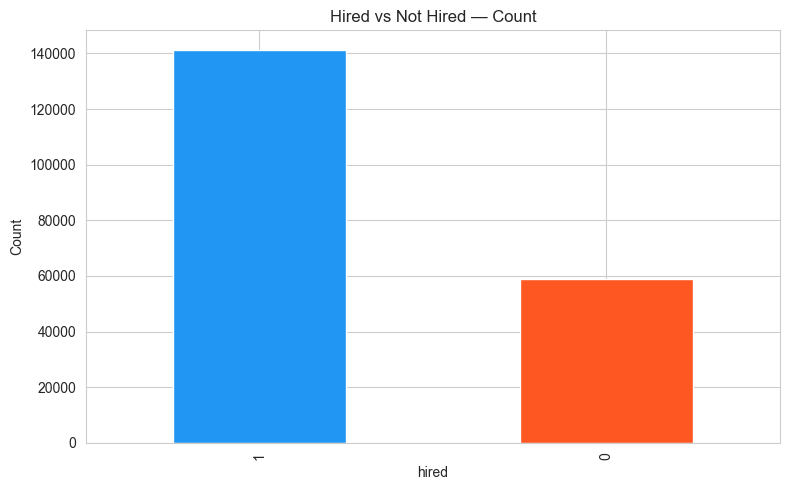

Ratio 2.40 is below 3.0 → imbalance is mild, but we'll still apply SMOTE since it's configured, and it won't hurt.


In [2]:
counts = df[target].value_counts()
print("Class counts:")
print(counts)

majority = counts.max()
minority = counts.min()
imbalance_ratio = majority / minority
print(f"\nImbalance ratio (majority / minority): {imbalance_ratio:.2f}")

fig, ax = plt.subplots()
counts.plot(kind="bar", ax=ax, color=["#2196F3", "#FF5722"])
ax.set_title("Hired vs Not Hired — Count")
ax.set_xlabel(target)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

if imbalance_ratio > 3.0:
    print(f"Ratio {imbalance_ratio:.2f} is above 3.0 → the imbalance is severe. "
          f"SMOTE is justified and already enabled in config.yaml.")
else:
    print(f"Ratio {imbalance_ratio:.2f} is below 3.0 → imbalance is mild, but we'll still "
          f"apply SMOTE since it's configured, and it won't hurt.")


### -- Hired is a binary column, 0 or 1
if one of these two values shows up far more than the other, a model could just keep guessing the bigger class and still look accurate without actually learning anything. that's why we are checking the ratio between the two counts here.

### -- the ratio tells us if SMOTE is actually needed
if majority divided by minority comes out above 3.0, the imbalance is bad enough that we will need SMOTE later while training. this 3.0 cutoff is already written into config.yaml, so we are not picking a random number here.


### before SMOTE and after SMOTE, just to see it
we are not applying SMOTE for real here, this is only a preview so we can see what it does. the actual SMOTE step happens inside train.py, only on the training split, never on the full dataset — doing it before the split would leak test information into training.


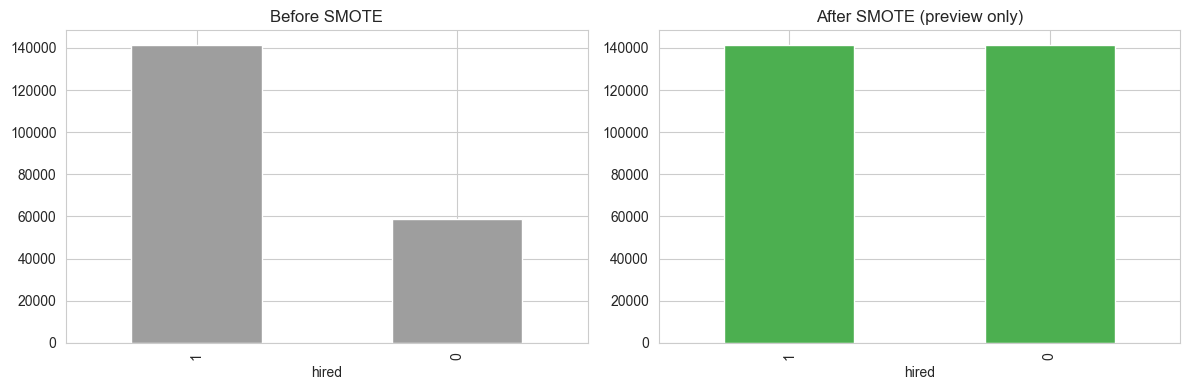

In [3]:
from imblearn.over_sampling import SMOTE

preview_df = df.copy()
num_cols = feat_cfg["numerical_features"]

X_preview = preview_df[num_cols].fillna(preview_df[num_cols].median())
y_preview = preview_df[target]

sm = SMOTE(random_state=cfg["smote"]["random_state"])
X_res, y_res = sm.fit_resample(X_preview, y_preview)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_preview.value_counts().plot(kind="bar", ax=axes[0], color="#9E9E9E", title="Before SMOTE")
pd.Series(y_res).value_counts().plot(kind="bar", ax=axes[1], color="#4CAF50", title="After SMOTE (preview only)")
plt.tight_layout()
plt.show()


### -- SMOTE does not just copy the minority rows
it creates new synthetic rows that sit in between the real minority rows, so the bar chart on the right looks balanced but those extra rows did not exist in the original data, they were generated.


## CORRELATION HEATMAP


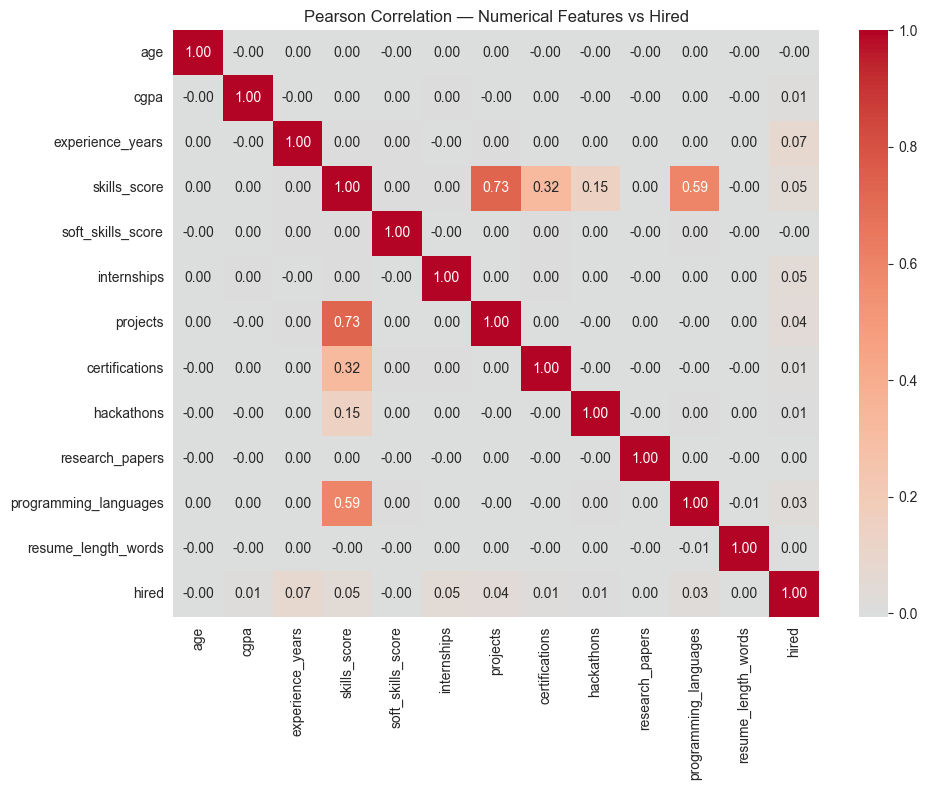

Top 5 predictors (by |correlation| with Hired):
experience_years         0.074603
internships              0.047885
skills_score             0.045687
projects                 0.035384
programming_languages    0.025373
Name: hired, dtype: float64


In [4]:
num_cols = feat_cfg["numerical_features"]
corr_df = df[num_cols + [target]].copy()
corr = corr_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pearson Correlation — Numerical Features vs Hired")
plt.tight_layout()
plt.show()

top5 = corr[target].drop(target).abs().sort_values(ascending=False).head(5)
print("Top 5 predictors (by |correlation| with Hired):")
print(top5)


### -- this tells us which numeric columns actually move with Hired
Pearson correlation only catches straight-line relationships, value between -1 and 1. we are taking the absolute value before ranking the top 5, because a strong negative correlation is just as useful as a strong positive one, the sign only tells direction not strength.


## FEATURE VS CLASS BOXPLOTS


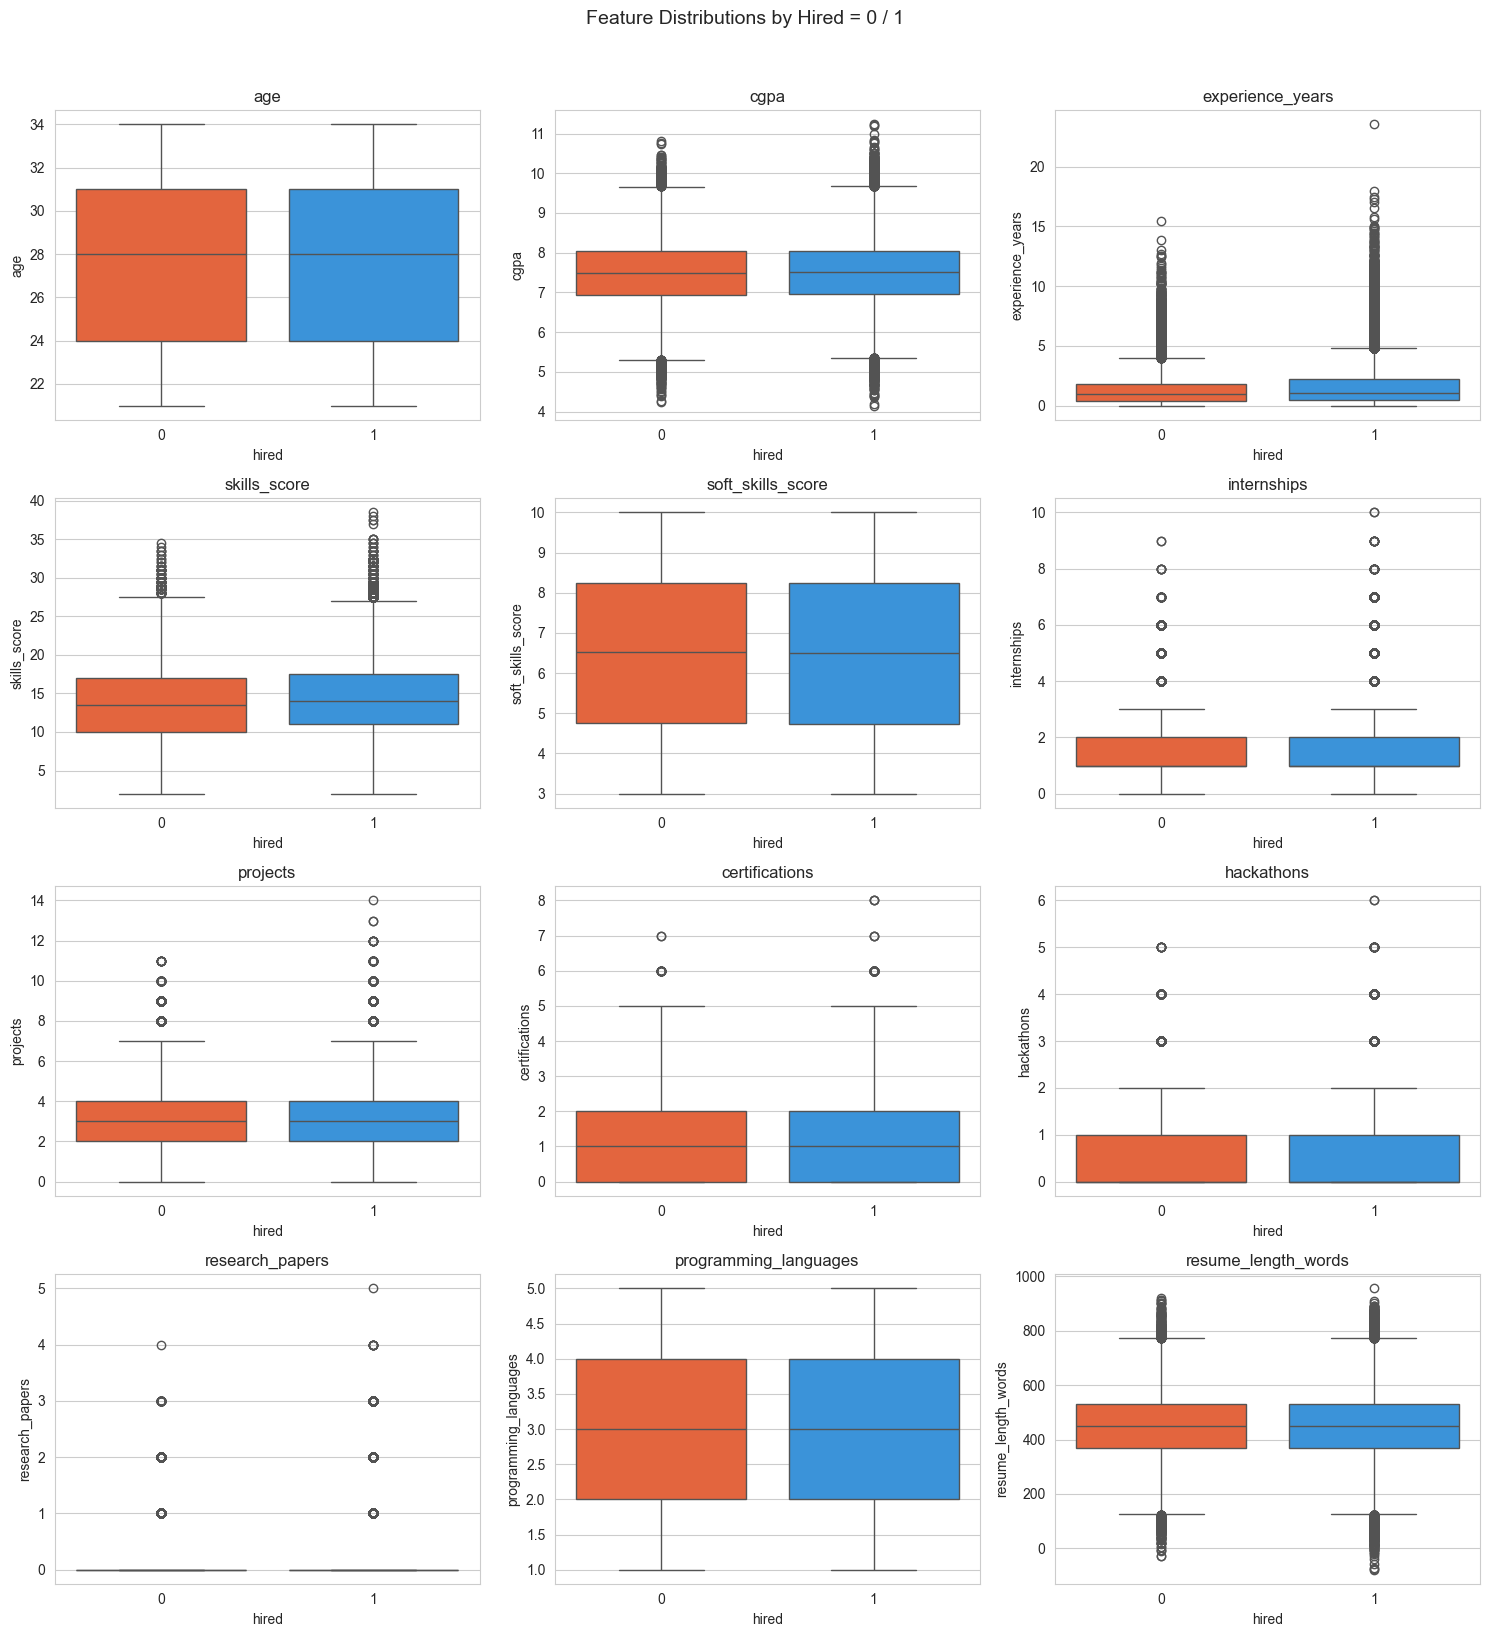

In [5]:
num_cols = feat_cfg["numerical_features"]
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i], hue=target, palette=["#FF5722", "#2196F3"], legend=False)
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distributions by Hired = 0 / 1", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### -- correlation alone is not enough
correlation can miss a feature that separates the classes in a non-straight-line way. so for every numeric feature we are plotting two boxplots side by side, one for Hired=0 and one for Hired=1. if the two boxes barely touch, that feature is doing a good job separating the classes. if they sit almost on top of each other, that feature is probably not pulling much weight for the model.


## MISSING VALUES AND OUTLIERS


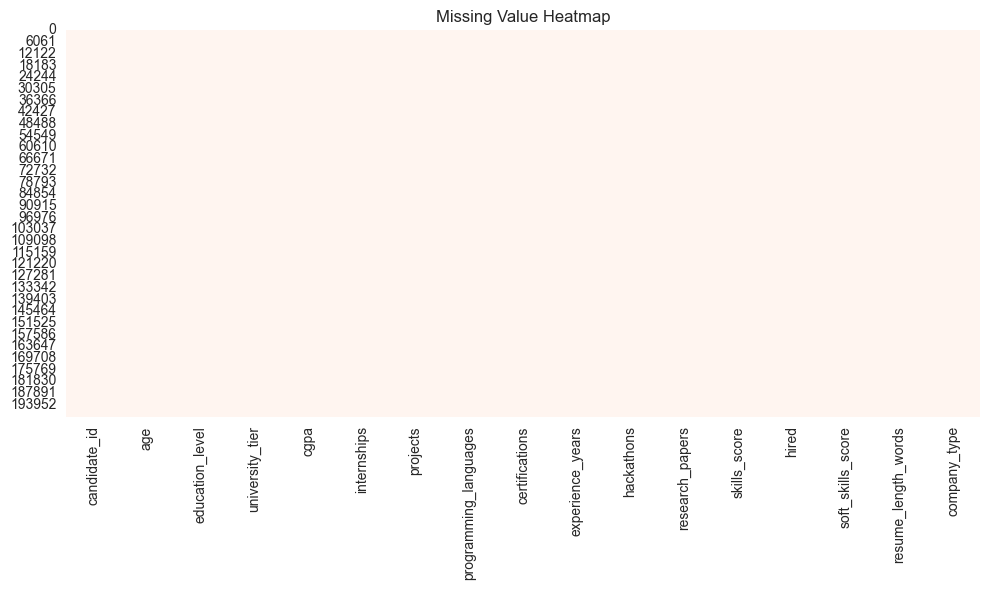

Missing values per column:
No missing values found.


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="Reds", ax=ax)
ax.set_title("Missing Value Heatmap")
plt.tight_layout()
plt.show()

null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No missing values found.")


### -- checking for null cells first
a model cannot work with an empty cell, every row needs a number in every column. this heatmap and the count below just shows us where the gaps are, before we decide how to fill them in preprocessing.py.


In [7]:
outlier_cols = feat_cfg["outlier_columns"]

print(f"{'Column':<20}{'Lower bound':>14}{'Upper bound':>14}{'# Outliers':>14}")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:<20}{lower:>14.2f}{upper:>14.2f}{n_outliers:>14}")

# diagnostic only — actual capping happens in src/preprocessing.py → handle_outliers()


Column                 Lower bound   Upper bound    # Outliers
age                          13.50         41.50             0
cgpa                          5.34          9.66          1456
experience_years             -2.04          4.55          9470
skills_score                  0.75         26.75          1219
soft_skills_score            -0.50         13.50             0


### -- now checking for outliers using the IQR rule
anything below Q1 minus 1.5 times the IQR, or above Q3 plus 1.5 times the IQR, counts as an outlier. this cell only counts and prints them, it does not change the data — the actual capping of these values happens later inside preprocessing.py.


## CATEGORICAL ANALYSIS



=== education_level ===
education_level
Bachelors    129827
Masters       60333
PhD            9840
Name: count, dtype: int64

Hiring rate by education_level:
education_level
PhD          0.707215
Bachelors    0.706502
Masters      0.704921
Name: hired, dtype: float64


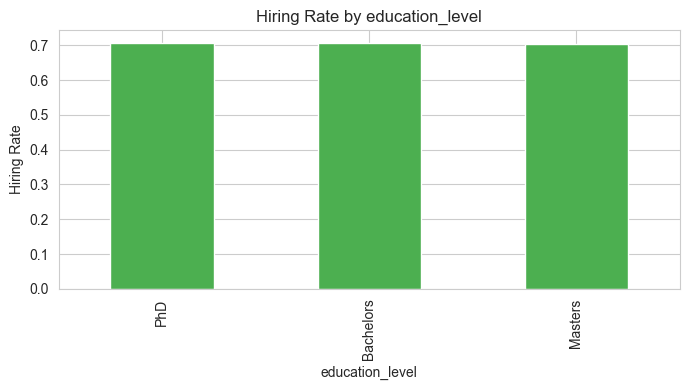


=== university_tier ===
university_tier
Tier 2    80182
Tier 1    59998
Tier 3    59820
Name: count, dtype: int64

Hiring rate by university_tier:
university_tier
Tier 1    0.706440
Tier 2    0.706318
Tier 3    0.705333
Name: hired, dtype: float64


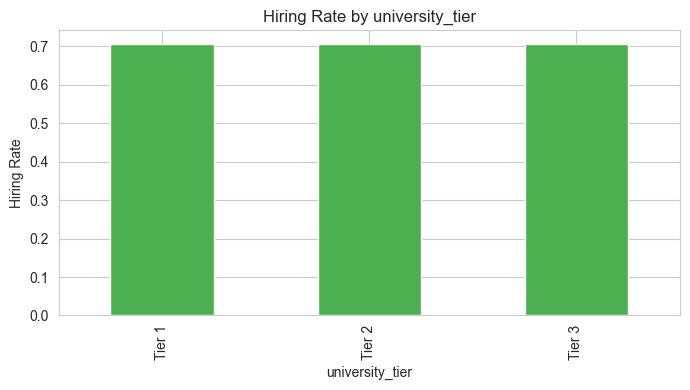


=== company_type ===
company_type
MNC         80187
Startup     69886
Mid-size    49927
Name: count, dtype: int64

Hiring rate by company_type:
company_type
Startup     0.707323
Mid-size    0.706532
MNC         0.704665
Name: hired, dtype: float64


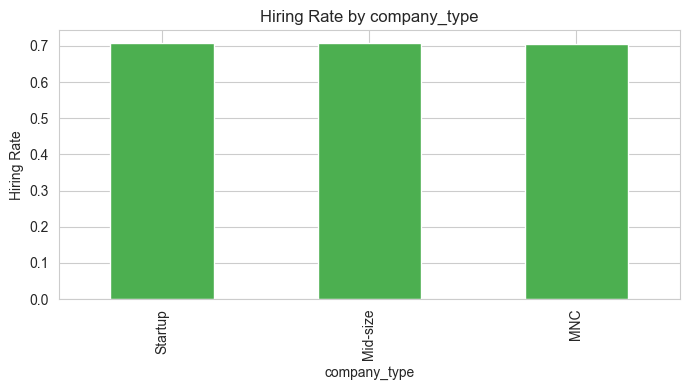

In [8]:
# pulled directly from features.yaml — no hardcoded column names here
cat_cols = feat_cfg["categorical_features"]  # ['education_level', 'university_tier', 'company_type']

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())

    hiring_rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    print(f"\nHiring rate by {col}:")
    print(hiring_rate)

    fig, ax = plt.subplots(figsize=(7, 4))
    hiring_rate.plot(kind="bar", ax=ax, color="#4CAF50")
    ax.set_title(f"Hiring Rate by {col}")
    ax.set_ylabel("Hiring Rate")
    plt.tight_layout()
    plt.show()


### -- looking at the category columns now
for education_level, university_tier and company_type, we are first checking how many rows fall under each category, then checking the average hired value per category, since hired is 0 or 1 the average works out as a hiring rate. the bar chart makes it easy to spot which categories tend to get hired more.


## SUMMARY

- Imbalance ratio: 2.40 (hired=1: 141,212 / hired=0: 58,788). Below the 3.0 threshold
  so imbalance is mild, but SMOTE is still applied as configured.

- Top 5 predictors (by |correlation| with hired):
  1. experience_years    0.075
  2. internships         0.048
  3. skills_score        0.046
  4. projects            0.035
  5. programming_languages 0.025
  All correlations are weak — no single feature dominates linearly,
  which justifies combining them into engineered features.

- Features that visually separate classes best (from boxplots):
  experience_years and skills_score showed the most visible median
  shift between hired=0 and hired=1. Most other features had heavily
  overlapping distributions.

- Columns with missing values: None. All 200,000 rows are complete,
  no imputation was needed.

- Columns with notable outliers (IQR method):
  - experience_years: 9,470 outliers (upper cap 4.55 years)
  - cgpa: 1,456 outliers
  - skills_score: 1,219 outliers
  - age and soft_skills_score: 0 outliers
  All capped in preprocessing.py → handle_outliers(), not deleted.

- Categories with highest / lowest hiring rate:
  education_level  → PhD highest (70.7%), Masters lowest (70.5%) — negligible gap
  university_tier  → Tier 1 highest (70.6%), Tier 3 lowest (70.5%) — negligible gap
  company_type     → Startup highest (70.7%), MNC lowest (70.5%) — negligible gap
  Key insight: categorical features show almost no hiring rate difference
  across categories, meaning they contribute little signal on their own.